---
#### 4-1. ML 실습 - 분류2 
- Titanic (https://www.kaggle.com/competitions/titanic/data)
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

In [2]:
# data loading 
train = pd.read_csv("data/titanic_train.csv")
test = pd.read_csv("data/titanic_test.csv")

print(train.shape, test.shape)
display(train.head())
display(test.head())

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
# 기초통계량
display(train.describe())
display(train.describe(include='object'))

# 결측치
display('NA of train =', train.isnull().sum())
display('NA of test =', test.isnull().sum())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


'NA of train ='

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

'NA of test ='

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [4]:
# 생존여부에 영향을 미치는 변수 (수치형)
corr = train.corr(numeric_only=True)
corr['Survived'].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [5]:
# 생존여부에 영향을 미치는 변수 (범주형)
print(train.groupby('Sex')['Survived'].mean())
print('-'*100)
print(train.groupby('Embarked')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
----------------------------------------------------------------------------------------------------
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


- 수치형, 범주형 변수 혼재됨 --> 인코딩 필요 
- PassengerId는 단순 일련번호, Name은 이름 --> 분석에 무의미 
- Ticket, Cabin은 고유한 개수가 너무 많음 --> 분석대상 제외 
- Age, Embarked에 결측치 존재 (test의 Fare에도 결측치 존재함 주의) --> 대체 
- Fare, Pclass, Sex, Embarked가 생존여부에 높은 영향을 미친 듯함 

In [6]:
# 분석에 불필요한 컬럼 제거 
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train = train.drop(columns=drop_cols, axis=1)
test = test.drop(columns=drop_cols, axis=1)

In [7]:
# 결측치 처리 : Age -> 평균값, Embarked -> 최빈값, test의 Fare -> 평균값
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])

test['Fare'] = test['Fare'].fillna(test['Fare'].mean())  

## 확인 
print(train.isnull().sum())
print(test.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [8]:
# 1차 데이터셋 완료 
display(train.head())
display(test.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


---

In [9]:
# 범주형 변수 인코딩 : Sex, Embarked
full = pd.concat([train, test], axis=0)
full = pd.get_dummies(full, drop_first=True, dtype=int)

train = full.iloc[:891, :]
test = full.iloc[891:, :]

# test에서 Survived 삭제 
test = test.drop('Survived', axis=1)
print(train.shape, test.shape)

(891, 9) (418, 8)


In [10]:
# 타겟변수 분리 
y = train['Survived']
X = train.drop('Survived', axis=1)

# 검증 데이터 분리 
from sklearn.model_selection import train_test_split 
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(
    X_train.shape, X_valid.shape, y_train.shape, y_valid.shape
)

(712, 8) (179, 8) (712,) (179,)


In [11]:
# 수치형 변수 스케일링 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

---

In [12]:
# modeling & eval 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score 

lr = LogisticRegression(random_state=120)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_valid)
y_pred_proba = lr.predict_proba(X_valid)[:, 1]

print("Accuracy:", round(accuracy_score(y_valid, y_pred), 4))
print("F1 score:", round(f1_score(y_valid, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, y_pred_proba), 4))

Accuracy: 0.8045
F1 score: 0.7244
ROC-AUC: 0.8433


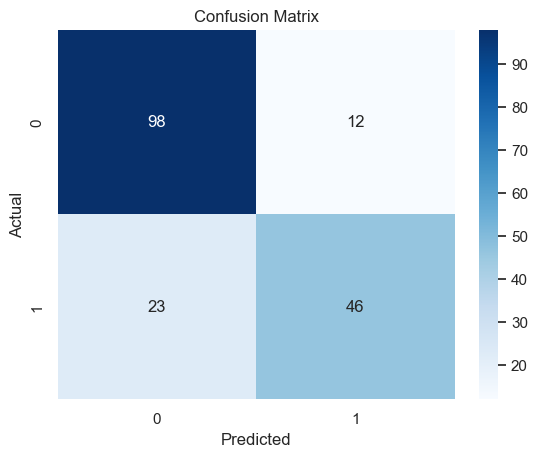

In [13]:
# 참고. 혼돈행렬 시각화 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_valid, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# 테스트에 적용, 결과파일 제출 
test_pred = lr.predict(test)

submission = pd.read_csv("data/gender_submission.csv") 
submission['Survived'] = test_pred
submission.to_csv("titanic_lr_submission.csv", index=False)

---
#### 참고. other models 
---

In [19]:
# ------------------------------
# 1. Data loading
# ------------------------------
train = pd.read_csv("data/titanic_train.csv")
test = pd.read_csv("data/titanic_test.csv")

# ------------------------------
# 2. 분석에 불필요한 컬럼 제거 
# ------------------------------
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train = train.drop(columns=drop_cols, axis=1)
test = test.drop(columns=drop_cols, axis=1)

# ------------------------------
# 3. 결측치 처리 : Age -> 평균값, Embarked -> 최빈값, test의 Fare -> 평균값
# ------------------------------
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])

test['Fare'] = test['Fare'].fillna(test['Fare'].mean())  

# ------------------------------
# 4. 범주형 변수 인코딩 : Sex, Embarked
# ------------------------------
full = pd.concat([train, test], axis=0)
full = pd.get_dummies(full, drop_first=True, dtype=int)

train = full.iloc[:891, :]
test = full.iloc[891:, :]
# test에서 Survived 삭제 
test = test.drop('Survived', axis=1)

# ------------------------------
# 5. 타겟변수 분리 
# ------------------------------
y = train['Survived']
X = train.drop('Survived', axis=1)

# ------------------------------
# 6. 검증 데이터 분리 
# ------------------------------
from sklearn.model_selection import train_test_split 
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ------------------------------
# 7. modeling & eval 
# ------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score 

dt = DecisionTreeClassifier(random_state=120)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_valid)
y_pred_proba = dt.predict_proba(X_valid)[:, 1]

print("==== Performance : DecisionTree ====")
print("Accuracy:", round(accuracy_score(y_valid, y_pred), 4))
print("F1 score:", round(f1_score(y_valid, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, y_pred_proba), 4))

==== Performance : DecisionTree ====
Accuracy: 0.8101
F1 score: 0.75
ROC-AUC: 0.784


In [17]:
# ------------------------------
# 7. modeling & eval 
# ------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score 

rf = RandomForestClassifier(random_state=120)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_valid)
y_pred_proba = rf.predict_proba(X_valid)[:, 1]

print("==== Performance : RandomForest ====")
print("Accuracy:", round(accuracy_score(y_valid, y_pred), 4))
print("F1 score:", round(f1_score(y_valid, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, y_pred_proba), 4))

==== Performance : RandomForest ====
Accuracy: 0.7989
F1 score: 0.7313
ROC-AUC: 0.8296


---
#### 모델간 성능 비교 
| Model               | Accuracy | F1 Score | ROC-AUC |  Description | 
|---------------------|----------|----------|----------|----------|
| LogisticRegression  | 0.8045   | 0.7244   | *0.8433   | 무난한 성능, 단 변수 전처리 과정 복잡 |
| DecisionTree        | *0.8101   | *0.7500   | 0.7840   |  Acc, F1은 높지만 ROC가 낮다 -> Overfitting 가능성  |
| RandomForest        | 0.7989   | 0.7313   | 0.8296   | 모든 평가지표에 비교적 안정적인 결과  |

---

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)


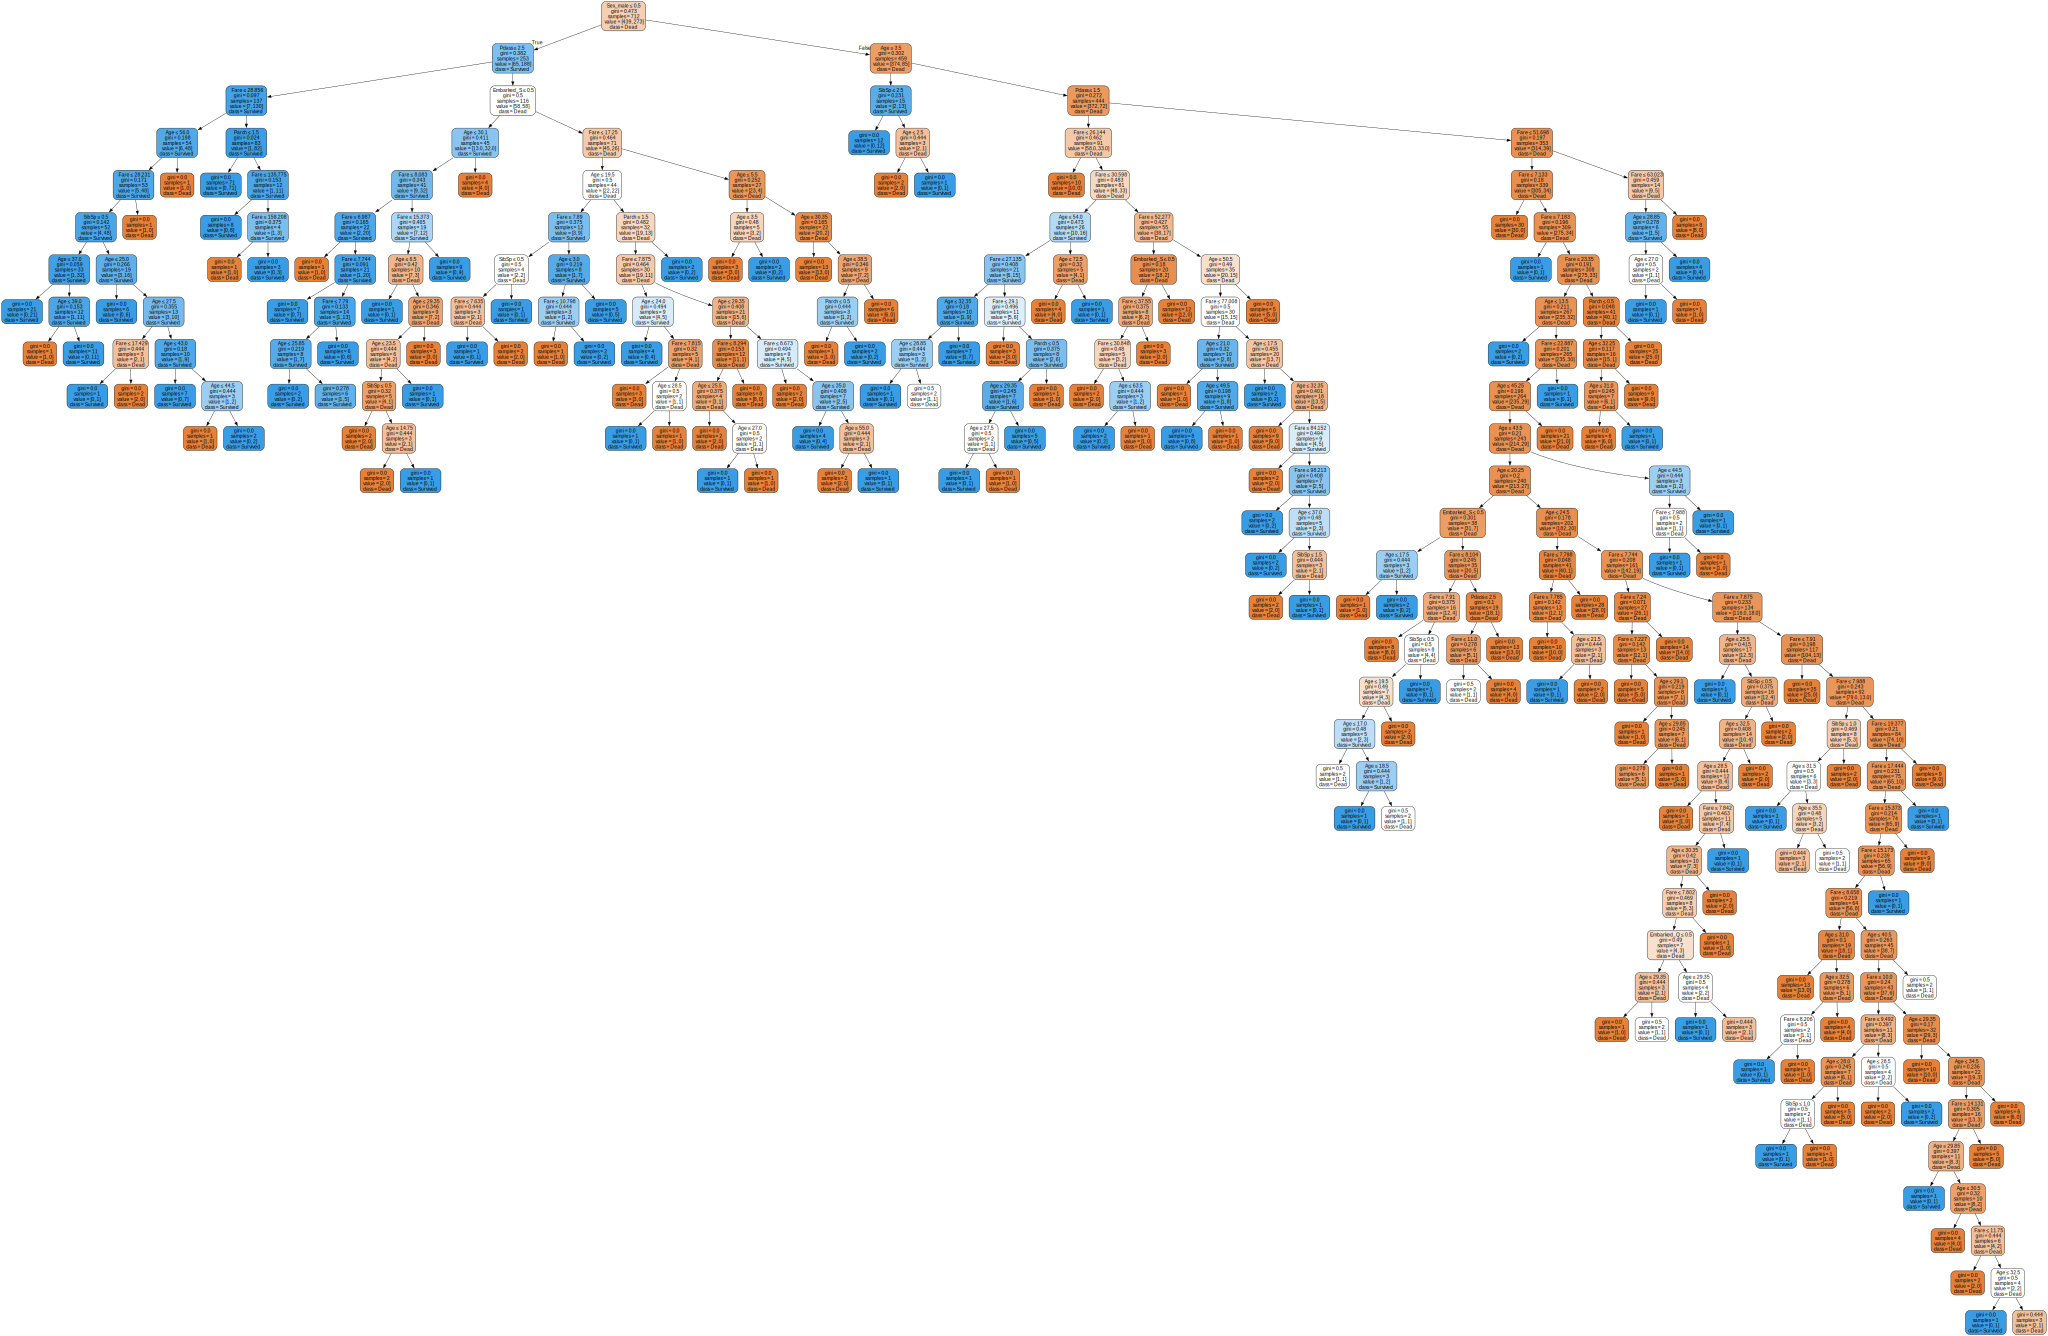

In [ ]:
## 참고. graphviz를 이용한 DecisionTree 결과 시각화 

#!pip install graphviz
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["Dead", "Survived"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph